# Assignment 1

**Assignment 1: Optimization**

**Goal**: ​Get familiar with gradient-based and derivative-free optimization by implementing these methods and applying them to a given function.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

In this assignment we are going to learn about **gradient-based** (GD) optimization methods and **derivative-free optimization** (DFO) methods. The goal is to implement these methods (one from each group) and analyze their behavior. Importantly, we aim at noticing differences between these two groups of methods.

Here, we are interested in ​minimizing​ the following function:

$$
f(\mathbf{x})=x_{1}^{2}+2 x_{2}^{2}-0.3 \cos \left(3 \pi x_{1}\right)-0.4 \cos \left(4 \pi x_{2}\right)+0.7
$$

in the domain $\mathbf{x} = (x_1, x_2) \in [-100, 100]^{2}$ (i.e., $x_1 \in [-100, 100]$, $x_2 \in [-100, 100]$).

In this assignemnt, you are asked to implement:
1. The gradient-descent algorithm.
2. A chosen derivative-free algorithm. *You are free to choose a method.*

After implementing both methods, please run experiments and compare both methods. Please find a more detailed description below.

## 1. Understanding the objective

Please run the code below and visualize the objective function. Please try to understand the objective function, what is the optimum (you can do it by inspecting the plot).

If any code line is unclear to you, please read on that in numpy or matplotlib docs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# PLEASE DO NOT REMOVE!
# The objective function.
def f(x):
    return (
        x[:, 0] ** 2
        + 2 * x[:, 1] ** 2
        - 0.3 * np.cos(3.0 * np.pi * x[:, 0])
        - 0.4 * np.cos(4.0 * np.pi * x[:, 1])
        + 0.7
    )

In [3]:
# PLEASE DO NOT REMOVE!
# Calculating the objective for visualization.
def calculate_f(x1, x2):
    f_x = []
    for i in range(len(x1)):
        for j in range(len(x2)):
            f_x.append(f(np.asarray([[x1[i], x2[j]]])))

    return np.asarray(f_x).reshape(len(x1), len(x2))

In [4]:
# PLEASE DO NOT REMOVE!
# Define coordinates
x1 = np.linspace(-100.0, 100.0, 400)
x2 = np.linspace(-100.0, 100.0, 400)

# Calculate the objective
f_x = calculate_f(x1, x2).reshape(len(x1), len(x2))

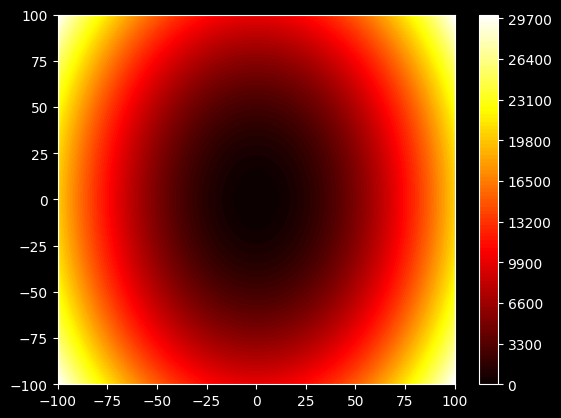

In [5]:
# PLEASE DO NOT REMOVE!
# Plot the objective
plt.contourf(x1, x2, f_x, 100, cmap="hot")
plt.colorbar()

## 2. The gradient-descent algorithm

First, you are asked to implement the gradient descent (GD) algorithm. Please take a look at the class below and fill in the missing parts.

NOTE: Please pay attention to the inputs and outputs of each function.

NOTE: To implement the GD algorithm, we need a gradient with respect to $\mathbf{x}$ of the given function. Please calculate it on a paper and provide the solution below. Then, implement it in an appropriate function that will be further passed to the GD class.

**Question 1 (0-1pt):** What is the gradient of the function $f(\mathbf{x})$? Please fill below both the mathematical expression and within the code.

**Answer:**
\begin{align*}
\nabla_{\mathbf{x}_1} f(\mathbf{x}) &= 2x_1 + 0.9\pi\sin(3\pi x_1)  \textbf{ (0.15 pt)}\\
\nabla_{\mathbf{x}_2} f(\mathbf{x}) &= 4x_2 + 1.6\pi\sin(4\pi x_2)  \textbf{ (0.15 pt)}\\
\end{align*}

In [6]:
# =========
# GRADING:
# 0
# 0.5pt - if properly implemented and commented well
# =========
# Implement the gradient for the considered f(x).
def grad(x):
    # ------
    # PLEASE FILL IN:
    # ...
    x = np.asarray(x)   # x is (1, 2) matrix
    x1 = x[:, 0]        # x1 is a vector
    x2 = x[:, 1]        # x2 is a vector

    grad_dx1 = 2*x1 + (0.3*np.sin(3*np.pi*x1) * 3*np.pi)
    grad_dx2 = 4*x2 + (0.4*np.sin(4*np.pi*x2) * 4*np.pi)

    grad = np.stack((grad_dx1, grad_dx2), axis=1)  # (1, 2) # 0.7 pt
    # ------
    return grad

In [7]:
# =========
# GRADING:
# 0
# 0.5pt if properly implemented and commented well
# =========
# Implement the gradient descent (GD) optimization algorithm.
# It is equivalent to implementing the step function.
class GradientDescent(object):
    def __init__(self, grad, step_size=0.1):
        self.grad = grad
        self.step_size = step_size

    def step(self, x_old):
        # ------
        # PLEASE FILL IN:
        # ...
        x_new = x_old - self.step_size * self.grad(x_old)
        # ------
        return x_new

In [8]:
# PLEASE DO NOT REMOVE!
# An auxiliary function for plotting.
def plot_optimization_process(ax, optimizer, title):
    # Plot the objective function
    ax.contourf(x1, x2, f_x, 100, cmap="hot")

    # Init the solution
    x = np.asarray([[90.0, -90.0]])
    x_opt = x
    # Run the optimization algorithm
    for i in range(num_epochs):
        x = optimizer.step(x)
        x_opt = np.concatenate((x_opt, x), 0)

    ax.plot(x_opt[:, 0], x_opt[:, 1], linewidth=3.0)
    ax.set_title(title)

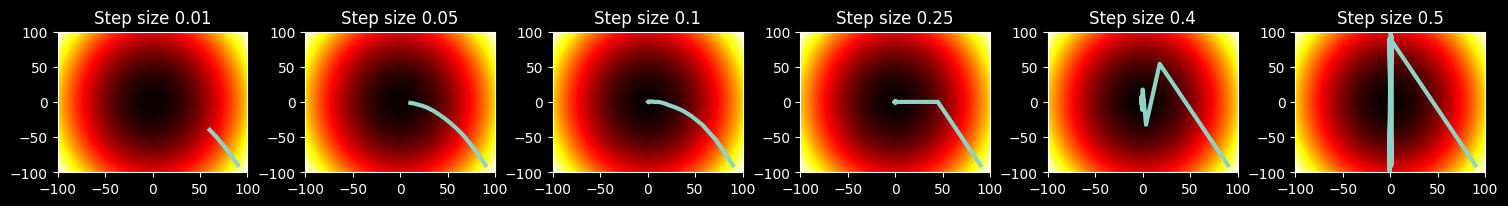

In [9]:
# PLEASE DO NOT REMOVE!
# This piece of code serves for the analysis.
# Running the GD algorithm with different step sizes
num_epochs = 20  # the number of epochs
step_sizes = [0.01, 0.05, 0.1, 0.25, 0.4, 0.5]  # the step sizes

# plotting the convergence of the GD
fig_gd, axs = plt.subplots(1, len(step_sizes), figsize=(15, 2))
fig_gd.tight_layout()

for i in range(len(step_sizes)):
    # take the step size
    step_size = step_sizes[i]
    # init the GD
    gd = GradientDescent(grad, step_size=step_size)
    # plot the convergence
    plot_optimization_process(
        axs[i], optimizer=gd, title="Step size " + str(gd.step_size)
    )

**Question 2 (0-0.5pt)**: Please analyze the plots above and comment on the behavior of the gradient-descent for different values of the step size. What happens in the small and large step sizes and what is the optimum step size?

**Answer**: The small step size undershot the global optimum and the large step size overshot the global optimum. I would say 0.1 or 0.25 were the optimal step sizes for this function.


**Question 3 (0-0.5pt)**: How can we improve the convergence when the step size equals 0.01? What about when the step size equals 0.5?

**Answer**: For 0.01 step size, I would increase the number of epochs or grow the step size.
For 0.5 step size, I would decay the step size as it converges and possibly lower epochs.

## 3. The derivative-free optimization

In the second part of this assignment, you are asked to implement a derivative-free optimziation (DFO) algorithm. Please notice that you are free to choose any DFO method you wish.
Moreover, you are encouraged to be as imaginative as possible! Do you have an idea for a new method or combine multiple methods? Great!

**Question 4 (0-0.5-1-1.5-2-2.5-3pt)**: Please provide a description (a pseudocode) of your DFO method here.

*NOTE (grading): Please keep in mind: start simple, make sure your approach works. You are encouraged to use your creativity and develop more complex approaches that will influence the grading. TAs will also check whether the pseudocode is correct.*

**Answer:**
The derivative-free optimization method I created uses a random local search with a growing/shrinking step size.
At each iteration, the algorithm samples multiple random candidate points around the current solution, evaluates the objective function at those points, and moves to the best candidate if an improvement is found.
The step size is increased after successful moves and decreased otherwise, allowing for fast convergence and fine-grained optimum estimation.

*Input:*
1. Objective function  f(x)
2. Number of random samples per iteration
3. Initial step size
4. Growth factor
5. Shrink factor
6. Seed

In [10]:
# =========
# GRADING: 0-0.5-1-1.5-2pt
# 0
# 0.5pt the code works but it is very messy and unclear
# 1.0pt the code works but it is messy and badly commented
# 1.5pt the code works but it is hard to follow in some places
# 2.0pt the code works and it is fully understandable
# =========
# Implement a derivative-free optimization (DFO) algorithm.
# REMARK: during the init, you are supposed to pass the obj_fun and other objects that are necessary in your method.


'''
My algorithm takes a random sample of points around the previous distribution and then picks
the one with the lowest height according to our objective function. If the height is lower than
t-1 (previous point), then grow the step size to increase guess speed, otherwise, shrink the step size
to hone in on the exact global optimum.
'''
class DFO(object):
    def __init__(self, obj_fun, num_points, step_size, grow, shrink, seed):
        self.obj_fun = obj_fun
        self.step_size = float(step_size)
        self.num_points = int(num_points)
        self.grow = grow
        self.shrink = shrink
        self.min_step = float(.00001)
        self.rng = np.random.default_rng(seed)
        # PLEASE FILL IN: You will need some other variables
        # ...

    ## PLEASE FILL IN IF NECESSARY
    ## Please remember that for the DFO you may need extra functions.


    def sample(self, x_old):            # samples a bunch of
        # Sample in a square x + step_size * U[-1,1]^2
        noise = self.rng.uniform(-1.0, 1.0, size=(self.num_points, 2))
        x_rand = x_old + self.step_size * noise      # (1, 2)
        return x_rand


    # This function MUST be implemented.
    # No additional arguments here!
    def step(self, x_old):
        x_old_height = self.obj_fun(x_old).item()      # have to resize to (1,1)
        x_rand = self.sample(x_old)                    # get a random sample

        # get height on each candidate, pass x_rand[i:i+1]
        vals = np.zeros(self.num_points)                    # initialize vals matrix with all zeros
        for i in range(self.num_points):
            vals[i] = self.obj_fun(x_rand[i:i+1]).item()    # have to resize to(1,1)

        best_i = int(np.argmin(vals))           # the best guess from vals[]
        x_best = x_rand[best_i:best_i+1]        # (1,2)
        best_i_height = float(vals[best_i])     # get its height too

        # greater than, move and grow step_size
        if best_i_height < x_old_height:
            self.step_size *= self.grow
            return x_best

        # less than, stay and shrink step_size
        self.step_size = max(self.min_step, self.step_size * self.shrink)
        return x_old



In [1]:
# PLEASE DO NOT REMOVE!
# Running the DFO algorithm with different step sizes
num_epochs = 15  # the number of epochs (you may change it!)

## PLEASE FILL IN
## Here all hyperparameters go.
## Please analyze at least one hyperparameter in a similar manner to the
## step size in the GD algorithm.
# ...
dfo_step_sizes = [0.1, 0.25, 0.4, 0.5, 0.75, 1, 2]  # the step sizes

## plotting the convergence of the DFO
## Please uncomment the two lines below, but please provide the number of axes (replace HERE appriopriately)
fig_dfo, axs = plt.subplots(1, len(dfo_step_sizes), figsize=(15, 2))
fig_dfo.tight_layout()

# the for-loop should go over (at least one) parameter(s) (replace HERE appriopriately)
# and uncomment the line below
for i in range(len(dfo_step_sizes)):
##    PLEASE FILL IN
#     ...

    step_size = dfo_step_sizes[i]
    grow = 1.75
    shrink = 0.5

#     plot the convergence
#     please change the title accordingly!
#     plot_optimization_process(axs[i], optimizer=dfo, title="")

    dfo = DFO(f, num_points=50, step_size=step_size, grow=grow, shrink=shrink, seed=42)
    plot_optimization_process(
        axs[i], optimizer=dfo, title=f"Step={str(step_size)}\nGrow={str(grow)}, Shrink={str(shrink)}"
    )


NameError: name 'plt' is not defined

**Question 5 (0-0.5-1pt)** Please comment on the behavior of your DFO algorithm. What are the strong points? What are the (potential) weak points? During working on the algorithm, what kind of problems did you encounter?

**Answer:** My algorithm is similar to random local search, but with a variable that grows and shrinks the step size.
- Strengths: For this objective function, the algorithm consistently reached the global minimum across many initial step sizes. With a starting step size of 2, grow of 1.75 and shrink of 0.5, it reached global minimum in just 7 epochs! Using the optimized combination of step, grow and shrink, for a given function, this algorithm will converge extremely fast.
- Weaknesses: Underneath non-convex functions, I am confident this algorithm will not work as well. With the right combination of step, grow and shrink it may work for some, but not for all.

## 4. Final remarks: GD vs. DFO

Eventually, please answer the following last question that will allow you to conclude the assignment draw conclusions.

**Question 6 (0-0.5pt)**: What are differences between the two approaches?

**Answer**: \
Gradient Descent:
- Relies heavily on exact information like knowing the gradient function.
- Extremely precise
- Very efficient
- Better for convex functions
---
Derivative Free Optimization:
- Does not require the gradient
- More computationally expensive
- Less predictable
- Flexible
- Robust

**Question 7 (0-0.5)**: Which of the is easier to apply? Why? In what situations? Which of them is easier to implement in general?

**Answer**: Generally, DFO seems easier to apply because the gradient isnt needed and the same algorithm could work for just about any function. The right DFO would probably out-perform Gradient Descent on the benchmark functions because of their highly complex shapes and patterns. In general, I would stick to Gradient Descent because it is faster and more precise, and will work more often than not.